In [1]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt

<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
C:\Users\MSI\AppData\Local\Temp\ipykernel_2408\3531890490.py:11: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('$\eta^(t)$')


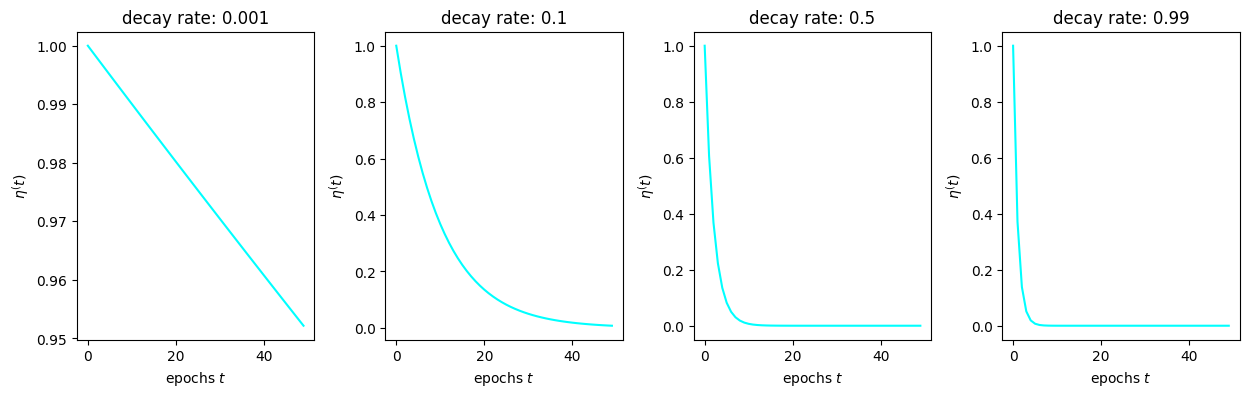

In [2]:
epochs = np.arange(0, 50)
lr_decay = [0.001, 0.1, 0.5, 0.99]
fig,ax = plt.subplots(nrows=1, ncols=4, figsize=(15,4))
plt_ind = np.arange(4) + 141
for decay, ind in zip(lr_decay, plt_ind):
    plt.subplot(ind)
    learn_rate = np.exp(-epochs * decay)
    plt.plot(epochs, learn_rate, c='cyan')
    plt.title('decay rate: ' + str(decay))
    plt.xlabel('epochs $t$')
    plt.ylabel('$\eta^(t)$')
fig.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
C:\Users\MSI\AppData\Local\Temp\ipykernel_2408\2903965681.py:9: SyntaxWarning: invalid escape sequence '\s'
  plt.title('$\sigma^2$ = ' + str(s))


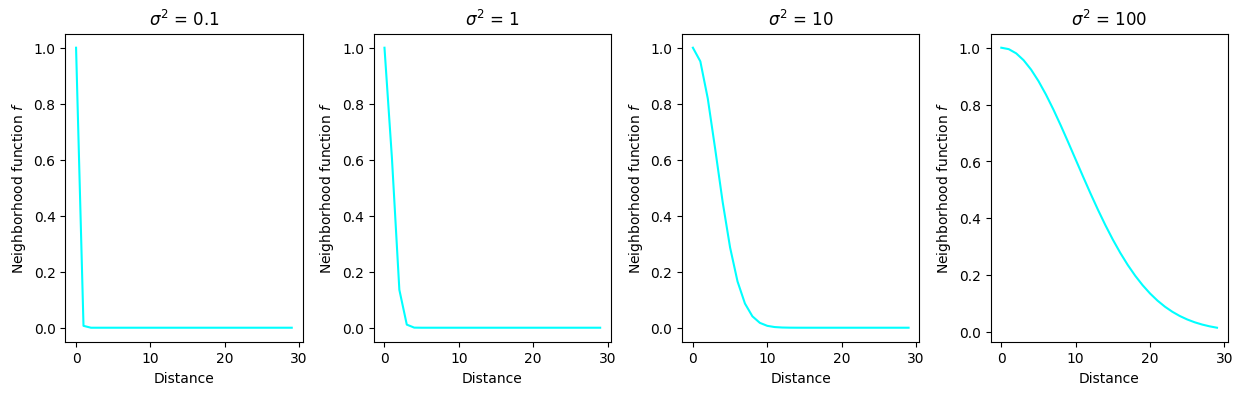

In [3]:
distance = np.arange(0, 30)
sigma_sq = [0.1, 1, 10, 100]
fig,ax = plt.subplots(nrows=1, ncols=4, figsize=(15,4))
plt_ind = np.arange(4) + 141
for s, ind in zip(sigma_sq, plt_ind):
    plt.subplot(ind)
    f = np.exp(-distance ** 2 / 2 / s)
    plt.plot(distance, f, c='cyan')
    plt.title('$\sigma^2$ = ' + str(s))
    plt.xlabel('Distance')
    plt.ylabel('Neighborhood function $f$')
fig.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

In [5]:
# Return the (g,h) index of the BMU in the grid
def find_BMU(SOME,x):
    distSq = (np.square(SOME - x)).sum(axis=2)
    return np.unravel_index(np.argmin(distSq, axis=None), distSq.shape)
    
# Update the weights of the SOME cells when given a single training example
# and the model parameters along with BMU coordinates as a tuple
def update_weights(SOME, train_ex, learn_rate, radius_sq, 
                   BMU_coord, step=3):
    g, h = BMU_coord
    #if radius is close to zero then only BMU is changed
    if radius_sq < 1e-3:
        SOME[g,h,:] += learn_rate * (train_ex - SOME[g,h,:])
        return SOME
    # Change all cells in a small neighborhood of BMU
    for i in range(max(0, g-step), min(SOME.shape[0], g+step)):
        for j in range(max(0, h-step), min(SOME.shape[1], h+step)):
            dist_sq = np.square(i - g) + np.square(j - h)
            dist_func = np.exp(-dist_sq / 2 / radius_sq)
            SOME[i,j,:] += learn_rate * dist_func * (train_ex - SOME[i,j,:])   
    return SOME    

# Main routine for training an SOME. It requires an initialized SOME grid
# or a partially trained grid as parameter
def train_SOM(SOME, train_data, learn_rate = .1, radius_sq = 1, 
             lr_decay = .1, radius_decay = .1, epochs = 10):    
    learn_rate_0 = learn_rate
    radius_0 = radius_sq
    for epoch in np.arange(0, epochs):
        rand.shuffle(train_data)      
        for train_ex in train_data:
            g, h = find_BMU(SOME, train_ex)
            SOME = update_weights(SOME, train_ex, 
                                 learn_rate, radius_sq, (g,h))
        # Update learning rate and radius
        learn_rate = learn_rate_0 * np.exp(-epoch * lr_decay)
        radius_sq = radius_0 * np.exp(-epoch * radius_decay)            
    return SOME

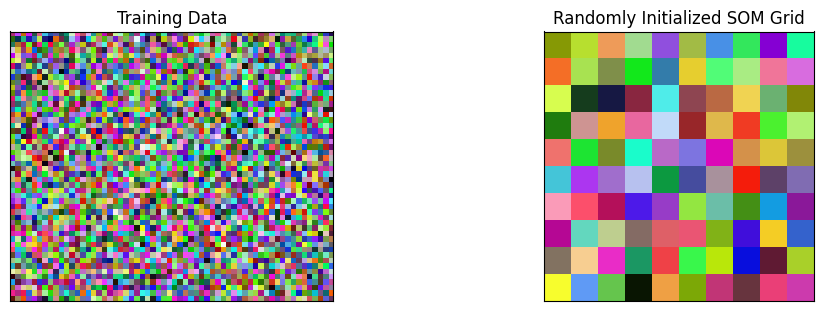

In [6]:
# Dimensions of the SOME grid
m = 10
n = 10
# Number of training examples
n_x = 3000
rand = np.random.RandomState(0)
# Initialize the training data
train_data = rand.randint(0, 255, (n_x, 3))
# Initialize the SOME randomly
SOME = rand.randint(0, 255, (m, n, 3)).astype(float)
# Display both the training matrix and the SOME grid
fig, ax = plt.subplots(
    nrows=1, ncols=2, figsize=(12, 3.5), 
    subplot_kw=dict(xticks=[], yticks=[]))
ax[0].imshow(train_data.reshape(50, 60, 3))
ax[0].title.set_text('Training Data')
ax[1].imshow(SOME.astype(int))
ax[1].title.set_text('Randomly Initialized SOME Grid')

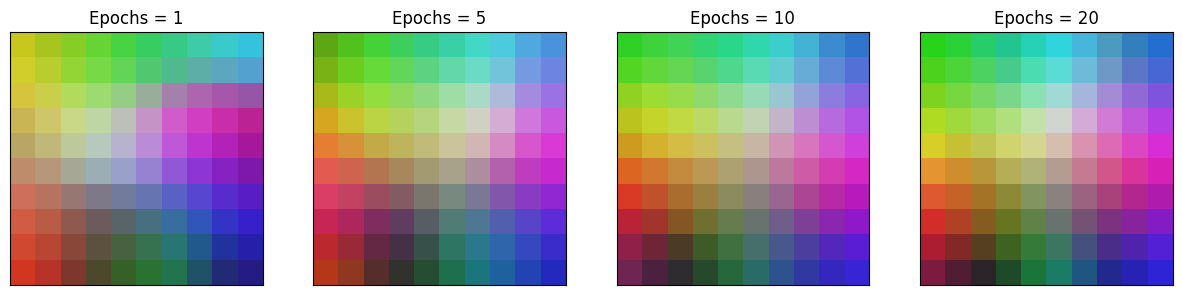

In [7]:
fig, ax = plt.subplots(
    nrows=1, ncols=4, figsize=(15, 3.5), 
    subplot_kw=dict(xticks=[], yticks=[]))
total_epochs = 0
for epochs, i in zip([1, 4, 5, 10], range(0,4)):
    total_epochs += epochs
    SOME = train_SOM(SOME, train_data, epochs=epochs)
    ax[i].imshow(SOME.astype(int))
    ax[i].title.set_text('Epochs = ' + str(total_epochs))

<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\s'
C:\Users\MSI\AppData\Local\Temp\ipykernel_2408\839696228.py:15: SyntaxWarning: invalid escape sequence '\e'
  ax[i][j].title.set_text('$\eta$ = ' + str(learn_rate) +
C:\Users\MSI\AppData\Local\Temp\ipykernel_2408\839696228.py:16: SyntaxWarning: invalid escape sequence '\s'
  ', $\sigma^2$ = ' + str(radius_sq))


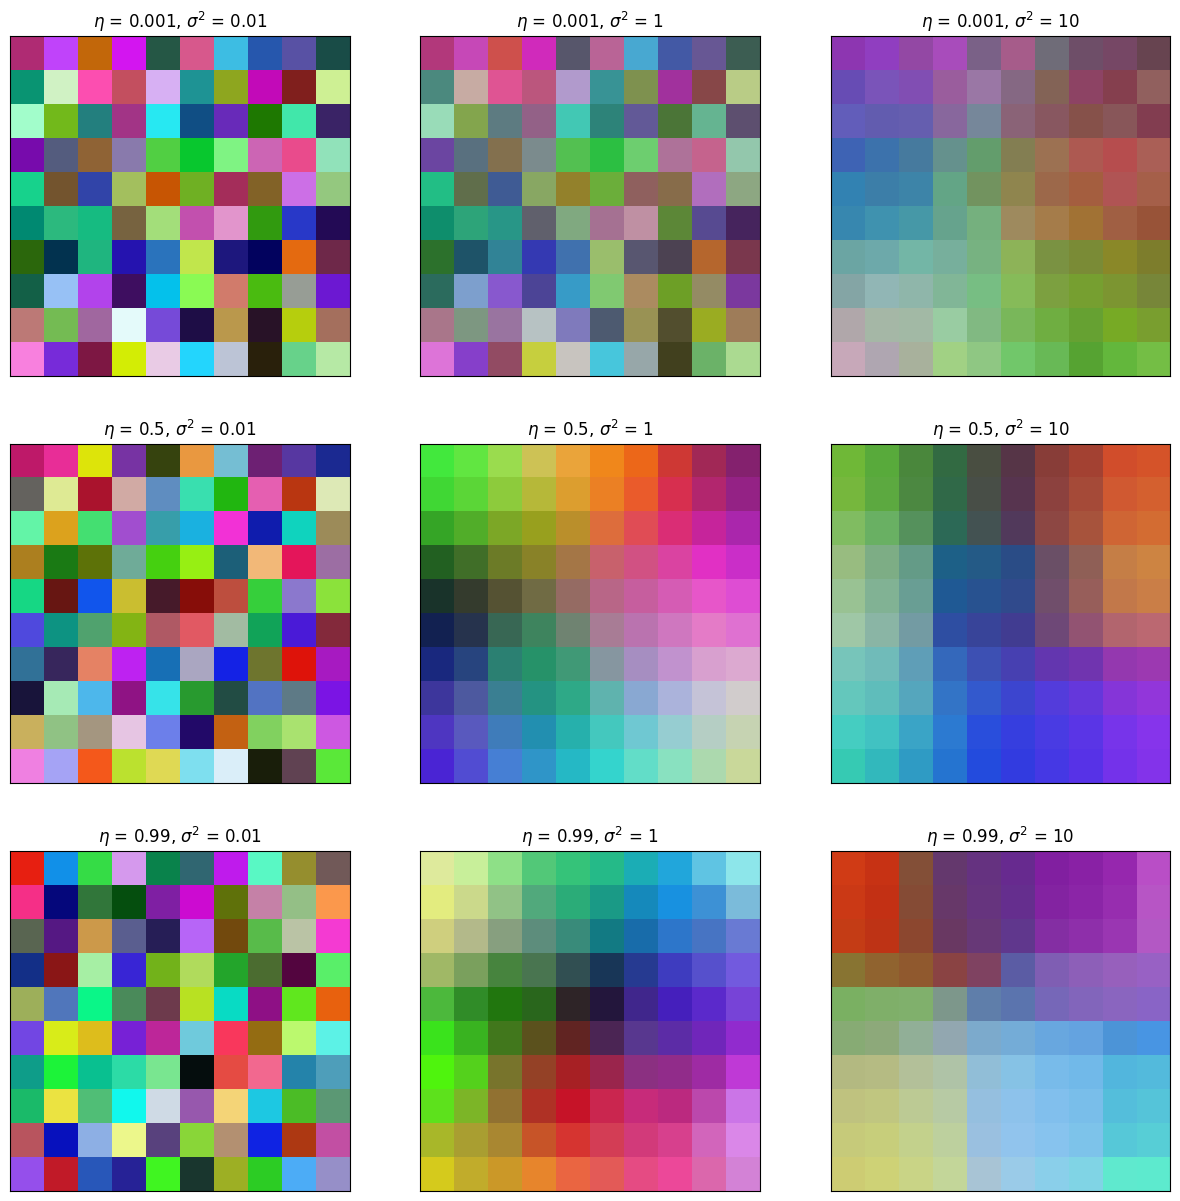

In [8]:
fig, ax = plt.subplots(
    nrows=3, ncols=3, figsize=(15, 15), 
    subplot_kw=dict(xticks=[], yticks=[]))

# Initialize the SOME randomly to the same state

for learn_rate, i in zip([0.001, 0.5, 0.99], [0, 1, 2]):
    for radius_sq, j in zip([0.01, 1, 10], [0, 1, 2]):
        rand = np.random.RandomState(0)
        SOME = rand.randint(0, 255, (m, n, 3)).astype(float)        
        SOME = train_SOM(SOME, train_data, epochs = 5,
                        learn_rate = learn_rate, 
                        radius_sq = radius_sq)
        ax[i][j].imshow(SOME.astype(int))
        ax[i][j].title.set_text('$\eta$ = ' + str(learn_rate) + 
                                ', $\sigma^2$ = ' + str(radius_sq))
                                